In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
import sys 
sys.path.append('..')
from config import UF, ANO, MES, RAW_DIR, PROCESSED_DIR, get_nome_arquivo

Dados carregados: 3267 linhas


In [ ]:
# Estilo dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

,CNES,CODUFMUN,REGSAUDE,MICR_REG,DISTRSAN,DISTRADM,TPGESTAO,PF_PJ,CPF_CNPJ,NIV_DEP,...,NIV_HIER,TERCEIRO,TP_LEITO,CODLEITO,QT_EXIST,QT_CONTR,QT_SUS,QT_NSUS,COMPETEN,NAT_JUR
0,0013102,410020,2,410020,,,D,3,00000000000000,3,...,,,2,33,3,0,3,0,202301,1244
1,0013129,410030,02,,,,D,3,00000000000000,3,...,,,5,45,1,0,1,0,202301,1244
2,0013129,410030,02,,,,D,3,00000000000000,3,...,,,4,43,1,0,1,0,202301,1244
3,0013129,410030,02,,,,D,3,00000000000000,3,...,,,2,33,10,0,10,0,202301,1244
4,2733528,410045,011,,,,M,3,00000000000000,3,...,,,4,10,2,0,2,0,202301,1244


In [ ]:
caminho_arquivo = RAW_DIR/ get_nome_arquivo('cnes')
df = pd.read_parquet(caminho_arquivo)

print(f"[CNES] Dados carregados")
print(f"   • Registros: {len(df):,} registros")
print(f"   • Colunas: {df.shape[1]}")
print(f"   • Tamanho: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

(3267, 28)

In [ ]:
#primeiras linhas
df.head()

['CNES',
 'CODUFMUN',
 'REGSAUDE',
 'MICR_REG',
 'DISTRSAN',
 'DISTRADM',
 'TPGESTAO',
 'PF_PJ',
 'CPF_CNPJ',
 'NIV_DEP',
 'CNPJ_MAN',
 'ESFERA_A',
 'ATIVIDAD',
 'RETENCAO',
 'NATUREZA',
 'CLIENTEL',
 'TP_UNID',
 'TURNO_AT',
 'NIV_HIER',
 'TERCEIRO',
 'TP_LEITO',
 'CODLEITO',
 'QT_EXIST',
 'QT_CONTR',
 'QT_SUS',
 'QT_NSUS',
 'COMPETEN',
 'NAT_JUR']

In [ ]:
#Lista de colunas
print(f"Colunas:")
print(f"{df.columns.to_list()}")

,0
CNES,object
CODUFMUN,object
REGSAUDE,object
MICR_REG,object
DISTRSAN,object
DISTRADM,object
TPGESTAO,object
PF_PJ,object
CPF_CNPJ,object
NIV_DEP,object


In [ ]:
#tipos de dados
print(f"Tipos de Dados:")
print(f"{df.dtypes}")

,0
CNES,518
CODUFMUN,238
REGSAUDE,45
MICR_REG,11
DISTRSAN,11
DISTRADM,3
TPGESTAO,3
PF_PJ,1
CPF_CNPJ,355
NIV_DEP,2


In [ ]:
df.columns.to_list()

,CNES,CODUFMUN,REGSAUDE,MICR_REG,DISTRSAN,DISTRADM,TPGESTAO,PF_PJ,CPF_CNPJ,NIV_DEP,...,NIV_HIER,TERCEIRO,TP_LEITO,CODLEITO,QT_EXIST,QT_CONTR,QT_SUS,QT_NSUS,COMPETEN,NAT_JUR
count,3267,3267,3267,3267,3267,3267,3267,3267,3267,3267,...,3267,3267,3267,3267,3267,3267,3267,3267,3267,3267
unique,518,238,45,11,11,3,3,1,355,2,...,1,1,7,64,88,1,77,52,1,21
top,7758391,410690,02,,,,M,3,00000000000000,1,...,,,1,33,2,0,0,0,202301,3999
freq,42,567,715,3123,2690,3198,1241,3267,658,2485,...,3267,3267,1090,376,537,3267,1032,1410,3267,1177


In [ ]:
df.dtypes

In [9]:
print(f"\nTipos de Leitos:")
print(df['TP_LEITO'].value_counts())


Tipos de Leitos:
TP_LEITO
1    1090
2     784
3     414
4     410
5     374
6     110
7      85
Name: count, dtype: int64


In [ ]:
#resumo do dataset
print("Resumo")
df.describe(include='all')

In [ ]:
#valores unicos
print("Valores únicos por coluna(5 maiores):")
nunique = df.nunique().sort_values(ascending=False)
print(nunique.head(5).to_string())
print("Valores únicos por coluna(5 menores):")
nunique = df.nunique().sort_values(ascending=True)
print(nunique.head(5).to_string())

In [ ]:
#valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos/len(df))* 100
df_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Percentual': nulos_pct
}).sort_values('Nulos', ascending=False)
print(f"Valores Nulos por coluna:")
df_nulos

In [ ]:
# Duplicatas
print("Análise de duplicatas:")

duplicatas = df.duplicated().sum()
print(f"   • Registros totais: {len(df):,}")
print(f"   • Duplicatas exatas: {duplicatas:,} ({duplicatas/len(df)*100:.2f}%)")

if duplicatas > 0:
    print(f"\n Existem duplicatas - serão removidas no agrupamento")

In [ ]:
print(f"\nTipos de Leitos:")
print(df['TP_LEITO'].value_counts())

In [10]:
df.columns = [col.upper() for col in df.columns]
print(f"Colunas padronizadas para maiúsculas")

Colunas padronizadas para maiúsculas


In [11]:
colunas_uteis = [
    'CNES',          # ID do hospital (chave)
    'CODUFMUN',      # Código do município
    'TP_LEITO',      # Tipo de leito
    'QT_EXIST',      # Total de leitos
    'QT_CONTR',      # Leitos contratados
    'QT_SUS',        # Leitos SUS
    'QT_NSUS',       # Leitos não SUS
    'ESFERA_A',      # Esfera (público, privado)
    'TP_UNID',       # Tipo de unidade
    'NIV_HIER',      # Nível hierárquico
    'NAT_JUR',       # Natureza jurídica
]

colunas_presentes = [col for col in colunas_uteis if col in df.columns]
colunas_faltando = [col for col in colunas_uteis if col not in df.columns]

print(f"Colunas presentes: {len(colunas_presentes)}")
print(f"Colunas faltando: {len(colunas_faltando)}")

if colunas_faltando:
    print(f"Colunas não encontradas: {colunas_faltando[:5]}")


Colunas presentes: 11
Colunas faltando: 0


In [12]:
df_selecionado = df[colunas_presentes].copy()

In [ ]:
#Mudar o tipo das colunas

df_selecionado['QT_EXIST'] = pd.to_numeric(df_selecionado['QT_EXIST'], errors='coerce').fillna(0).astype(int)
df_selecionado['QT_CONTR'] = pd.to_numeric(df_selecionado['QT_CONTR'], errors='coerce').fillna(0).astype(int)
df_selecionado['QT_SUS'] = pd.to_numeric(df_selecionado['QT_SUS'], errors='coerce').fillna(0).astype(int)
df_selecionado['QT_NSUS'] = pd.to_numeric(df_selecionado['QT_NSUS'], errors= 'coerce').fillna(0).astype(int)
df_selecionado.dtypes

QT_EXIST: convertido para int
QT_CONTR: convertido para int
QT_SUS: convertido para int
QT_NSUS: convertido para int


In [ ]:
colunas_leitos = ['QT_EXIST', 'QT_CONTR', 'QT_SUS', 'QT_NSUS']
for col in colunas_leitos:
    if col in df_selecionado.columns:
        df_selecionado[col] = pd.to_numeric(df_selecionado[col], errors='coerce').fillna(0).astype(int)
        print(f"{col}: convertido para int")

In [ ]:
#agrupamento por hospital
"""
Lógica de agrupamento:

   Cada hospital pode ter múltiplos registros no CNES, um para cada
   tipo de leito (ex: UTI, Enfermaria, Pediatria). Para análise de
   capacidade por hospital, agrupamos por:
   - CNES, CODUFMUN e características fixas do hospital
   - Somando os leitos de todos os tipos
"""
colunas_agrupar = [col for col in df_selecionado.columns if col not in colunas_leitos]
colunas_somar = [col for col in df_selecionado.columns if col in colunas_leitos]

print(f"Colunas para agrupar: {colunas_agrupar}")
print(f"Colunas para somar: {colunas_somar}")

# Agrupar
df_agrupado = df_selecionado.groupby(colunas_agrupar)[colunas_somar].sum().reset_index()

# Padronizar CNES (7 dígitos)
df_agrupado['CNES'] = df_agrupado['CNES'].astype(str).str.zfill(7)

print(f"Hospitais únicos: {len(df_agrupado):,}")
print(f"Colunas: {df_agrupado.columns.tolist()}")

Colunas para agrupar: ['CNES', 'CODUFMUN', 'TP_LEITO', 'ESFERA_A', 'TP_UNID', 'NIV_HIER', 'NAT_JUR']
Colunas para somar: ['QT_EXIST', 'QT_CONTR', 'QT_SUS', 'QT_NSUS']
Hospitais únicos: 1,717
Colunas: ['CNES', 'CODUFMUN', 'TP_LEITO', 'ESFERA_A', 'TP_UNID', 'NIV_HIER', 'NAT_JUR', 'QT_EXIST', 'QT_CONTR', 'QT_SUS', 'QT_NSUS']


In [15]:

for col in colunas_somar:
    if col in df_agrupado.columns:
        print(f"   • {col}:")
        print(f"      - Total: {df_agrupado[col].sum():,}")
        print(f"      - Média: {df_agrupado[col].mean():.2f}")
        print(f"      - Máximo: {df_agrupado[col].max():,}")
        print(f"      - Hospitais com 0: {(df_agrupado[col] == 0).sum()}")

   • QT_EXIST:
      - Total: 30,447
      - Média: 17.73
      - Máximo: 410
      - Hospitais com 0: 0
   • QT_CONTR:
      - Total: 0
      - Média: 0.00
      - Máximo: 0
      - Hospitais com 0: 1717
   • QT_SUS:
      - Total: 20,721
      - Média: 12.07
      - Máximo: 400
      - Hospitais com 0: 396
   • QT_NSUS:
      - Total: 9,726
      - Média: 5.66
      - Máximo: 120
      - Hospitais com 0: 833


In [16]:
caminho = '../data/processed/cnes_clean_PR_2023_01.parquet'
df_agrupado.to_parquet(caminho)

print(f"Dados salvos em: {caminho}")
print(f"   • Registros: {len(df_agrupado):,}")
print(f"   • Colunas: {len(df_agrupado.columns)}")

df_agrupado.head()

Dados salvos em: ../data/processed/cnes_clean_PR_2023_01.parquet
   • Registros: 1,717
   • Colunas: 11


,CNES,CODUFMUN,TP_LEITO,ESFERA_A,TP_UNID,NIV_HIER,NAT_JUR,QT_EXIST,QT_CONTR,QT_SUS,QT_NSUS
0,0013102,410020,2,,15,,1244,3,0,3,0
1,0013129,410030,2,,73,,1244,10,0,10,0
2,0013129,410030,4,,73,,1244,1,0,1,0
3,0013129,410030,5,,73,,1244,1,0,1,0
4,0013633,410400,1,,05,,3999,181,0,165,16


In [17]:
print("\nTop 10 hospitais por leito")
top_leitos = df_agrupado.nlargest(10, 'QT_EXIST')[['CNES', 'QT_EXIST', 'QT_SUS', 'TP_UNID']]
print(top_leitos.to_string(index=False))



Top 10 hospitais por leito
   CNES  QT_EXIST  QT_SUS TP_UNID
0013846       410     333      05
0018384       400     400      07
0013846       328     306      05
2573504       296     296      07
2578468       220     206      07
0015334       204     156      05
0013633       181     165      05
2587289       172     160      05
0016365       160     110      07
0018260       160     160      07



DISTRIBUIÇÃO DE LEITOS:
   • Total de leitos: 30,447
   • Média: 17.73
   • Mediana: 8
   • Máximo: 410
   • Hospitais com 0 leitos: 0


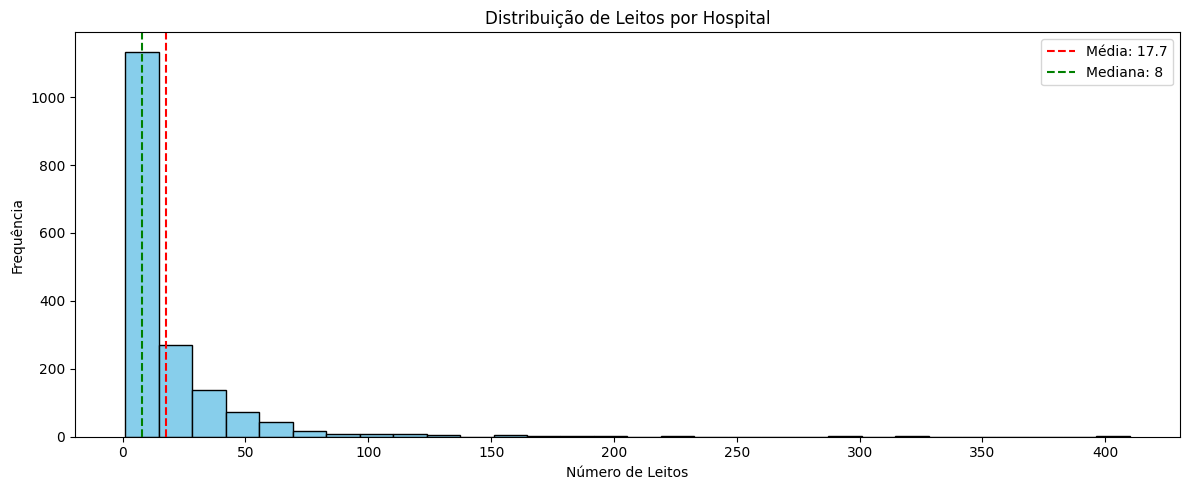

In [18]:
print("\nDISTRIBUIÇÃO DE LEITOS:")
print(f"   • Total de leitos: {df_agrupado['QT_EXIST'].sum():,}")
print(f"   • Média: {df_agrupado['QT_EXIST'].mean():.2f}")
print(f"   • Mediana: {df_agrupado['QT_EXIST'].median():.0f}")
print(f"   • Máximo: {df_agrupado['QT_EXIST'].max():,}")
print(f"   • Hospitais com 0 leitos: {(df_agrupado['QT_EXIST'] == 0).sum()}")

# Gráfico: Distribuição de leitos
plt.figure(figsize=(12, 5))
plt.hist(df_agrupado[df_agrupado['QT_EXIST'] > 0]['QT_EXIST'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Número de Leitos')
plt.ylabel('Frequência')
plt.title('Distribuição de Leitos por Hospital')
plt.axvline(df_agrupado['QT_EXIST'].mean(), color='red', linestyle='--', label=f'Média: {df_agrupado["QT_EXIST"].mean():.1f}')
plt.axvline(df_agrupado['QT_EXIST'].median(), color='green', linestyle='--', label=f'Mediana: {df_agrupado["QT_EXIST"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/02_distribuicao_leitos.png', dpi=150, bbox_inches='tight')
plt.show()



LEITOS SUS VS TOTAIS:
   • Total de leitos: 30,447
   • Leitos SUS: 20,721
   • % SUS: 68.06%


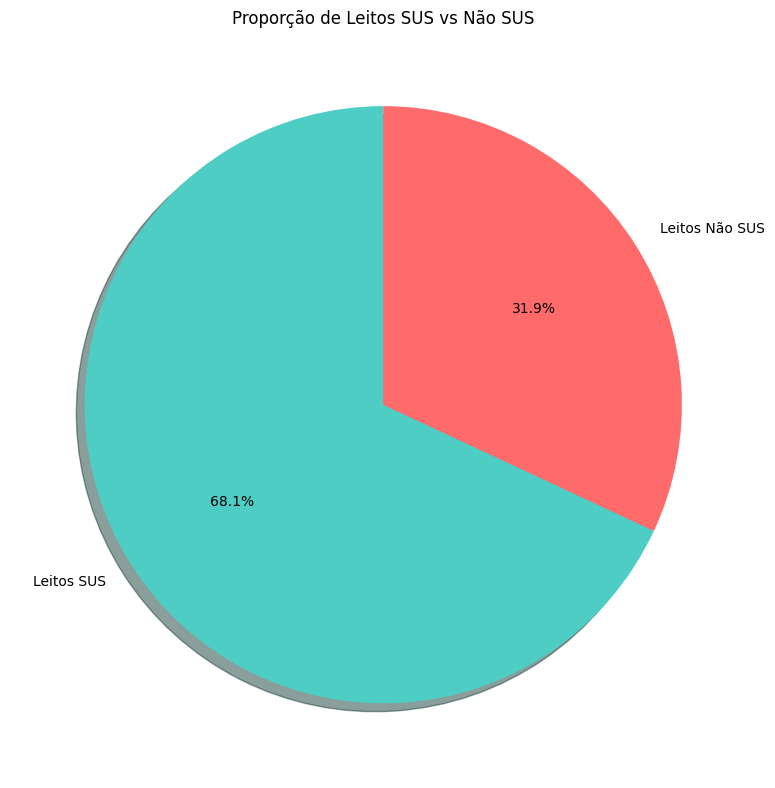

In [19]:
print("\nLEITOS SUS VS TOTAIS:")
total_leitos = df_agrupado['QT_EXIST'].sum()
total_sus = df_agrupado['QT_SUS'].sum()
print(f"   • Total de leitos: {total_leitos:,}")
print(f"   • Leitos SUS: {total_sus:,}")
print(f"   • % SUS: {(total_sus / total_leitos * 100):.2f}%")

# Gráfico de pizza
plt.figure(figsize=(8, 8))
labels = ['Leitos SUS', 'Leitos Não SUS']
sizes = [total_sus, total_leitos - total_sus]
colors = ['#4ecdc4', '#ff6b6b']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90, shadow=True)
plt.title('Proporção de Leitos SUS vs Não SUS')
plt.tight_layout()
plt.savefig('../reports/figures/02_leitos_sus_vs_total.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
if 'TP_UNID' in df_agrupado.columns:
    print("\nHOSPITAIS POR TIPO:")
    print(df_agrupado['TP_UNID'].value_counts())


HOSPITAIS POR TIPO:
TP_UNID
05    1464
07     114
62      64
70      22
73      18
15      17
36      12
20       5
83       1
Name: count, dtype: int64


In [21]:
if 'CODUFMUN' in df_agrupado.columns:
    print("\nTOP 10 MUNICÍPIOS POR LEITOS:")
    leitos_municipio = df_agrupado.groupby('CODUFMUN')['QT_EXIST'].sum().sort_values(ascending=False).head(10)
    for cod, qtd in leitos_municipio.items():
        print(f"   • {cod}: {qtd:,} leitos")


TOP 10 MUNICÍPIOS POR LEITOS:
   • 410690: 6,157 leitos
   • 411370: 2,351 leitos
   • 411520: 2,166 leitos
   • 410420: 1,377 leitos
   • 410480: 1,173 leitos
   • 411990: 853 leitos
   • 412810: 796 leitos
   • 411950: 726 leitos
   • 410830: 501 leitos
   • 410940: 490 leitos
